In [1]:
import torch
import torchvision
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm  # Pour la barre de progression
from pfe_data import PFEDataManager, MVTecDataset
from torch.utils.data import DataLoader

# Configuration pour des graphiques plus grands et lisibles
plt.rcParams['figure.figsize'] = (14, 6)
print("Bibliothèques chargées et environnement prêt.")

/Users/tatiananiauronis/Documents/PFE/csc8605/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


✅ Bibliothèques chargées et environnement prêt.


In [3]:
# 1. Connexion au DataManager
dm = PFEDataManager()

# 2. Création du Dataset (Split 'train' = Images saines uniquement)
train_ds = MVTecDataset(dm, table_name="mvtec_ad", split="train")

# 3. Création du DataLoader (Le camion de livraison)
BATCH_SIZE = 64
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

print(f"Loader initialisé avec succès.")
print(f"Nombre total d'images d'entraînement : {len(train_ds)}")
print(f"Images par paquet (Batch Size)       : {BATCH_SIZE}")

Loader initialisé avec succès.
Nombre total d'images d'entraînement : 7935
Images par paquet (Batch Size)       : 64


In [4]:
# Un paquet
images, labels = next(iter(train_loader))

print("INSPECTION DU PREMIER BATCH :")
print(f"--------------------------------")
print(f" Forme du tenseur Images : {images.shape}")
print(f"    {images.shape[0]} images")
print(f"    {images.shape[1]} canaux (Rouge, Vert, Bleu)")
print(f"    {images.shape[2]}x{images.shape[3]} pixels")
print(f"\n Plage de valeurs des pixels :")
print(f"   Min : {images.min():.4f} (Doit être proche de 0)")
print(f"   Max : {images.max():.4f} (Doit être proche de 1)")
print(f"\n Labels (0.0 pour 'Good') : \n{labels}")

🔍 INSPECTION DU PREMIER BATCH :
--------------------------------
 Forme du tenseur Images : torch.Size([64, 3, 256, 256])
    64 images
    3 canaux (Rouge, Vert, Bleu)
    256x256 pixels

 Plage de valeurs des pixels :
   Min : 0.0000 (Doit être proche de 0)
   Max : 1.0000 (Doit être proche de 1)

 Labels (Devraient être 0.0 pour 'Good') : 
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])


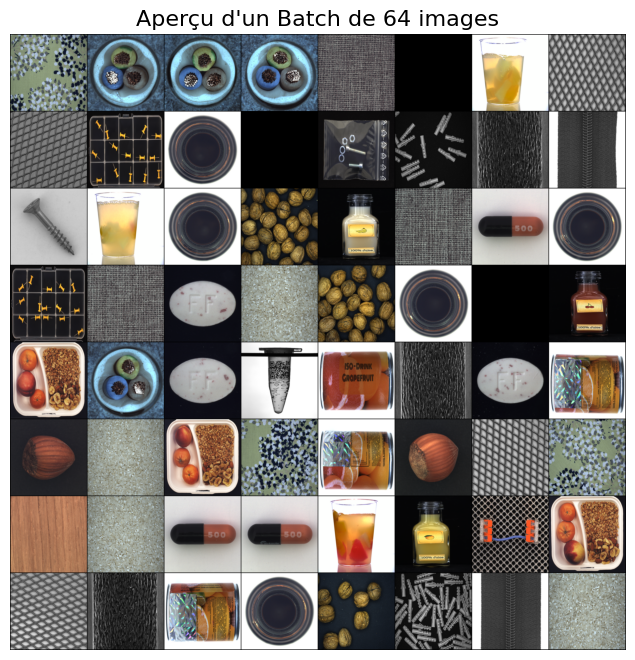

In [5]:
def show_batch_grid(img_tensor):
    # make_grid colle les images les unes à côté des autres
    grid_img = torchvision.utils.make_grid(img_tensor, nrow=8, padding=2)
    
    plt.figure(figsize=(16, 8))
    # On permute les dimensions : (C, H, W) -> (H, W, C) pour l'affichage
    plt.imshow(grid_img.permute(1, 2, 0))
    plt.axis('off')
    plt.title(f"Aperçu d'un Batch de {len(img_tensor)} images", fontsize=16)
    plt.show()

show_batch_grid(images)

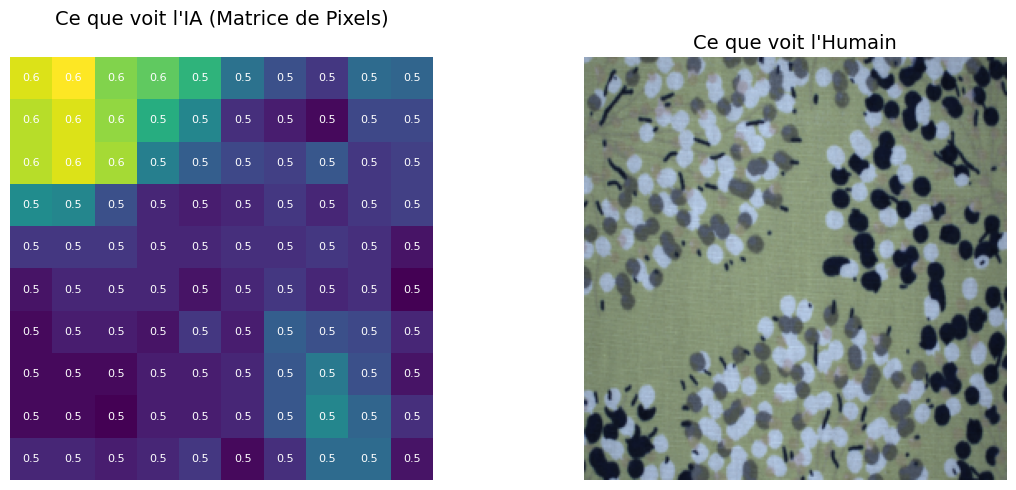

In [6]:
# On prend la première image du batch
single_img = images[0]

# Affichage mixte : Chiffres + Image
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

# 1. Les Maths (Extrait des pixels)
matrix_extract = single_img[0, :10, :10] # Coin haut-gauche du canal Rouge
ax[0].matshow(matrix_extract, cmap='viridis')
for (i, j), z in np.ndenumerate(matrix_extract):
    ax[0].text(j, i, '{:0.1f}'.format(z), ha='center', va='center', color='white', fontsize=8)
ax[0].set_title("Ce que voit l'IA (Matrice de Pixels)", fontsize=14)
ax[0].axis('off')

# 2. L'Image
ax[1].imshow(single_img.permute(1, 2, 0))
ax[1].set_title("Ce que voit l'Humain", fontsize=14)
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [23]:
def analyze_full_dataset(loader):
    print("Analyse statistique en cours sur tout le dataset...")
    
    channels_sum, channels_sq_sum, num_batches = 0, 0, 0
    total_samples = 0
    
    # Boucle rapide sans entraînement
    for data, _ in tqdm(loader):
        # Moyenne et écart-type par canal (R, G, B)
        channels_sum += torch.mean(data, dim=[0, 2, 3])
        channels_sq_sum += torch.mean(data ** 2, dim=[0, 2, 3])
        num_batches += 1
        total_samples += data.size(0)
    
    mean = channels_sum / num_batches
    std = (channels_sq_sum / num_batches - mean ** 2) ** 0.5
    
    print("\n RÉSULTATS GLOBAUX :")
    print(f"   Images analysées : {total_samples}")
    print(f"   Moyenne (RGB)    : {mean.tolist()}")
    print(f"   Écart-type (RGB) : {std.tolist()}")
    
    return mean, std

# On stocke ces valeurs, elles serviront peut-être à normaliser plus tard
global_mean, global_std = analyze_full_dataset(train_loader)

Analyse statistique en cours sur tout le dataset...


100%|██████████| 124/124 [1:00:47<00:00, 29.42s/it]


 RÉSULTATS GLOBAUX :
   Images analysées : 7935
   Moyenne (RGB)    : [0.40051499009132385, 0.3713741600513458, 0.3507196605205536]
   Écart-type (RGB) : [0.311443030834198, 0.30052894353866577, 0.294060617685318]


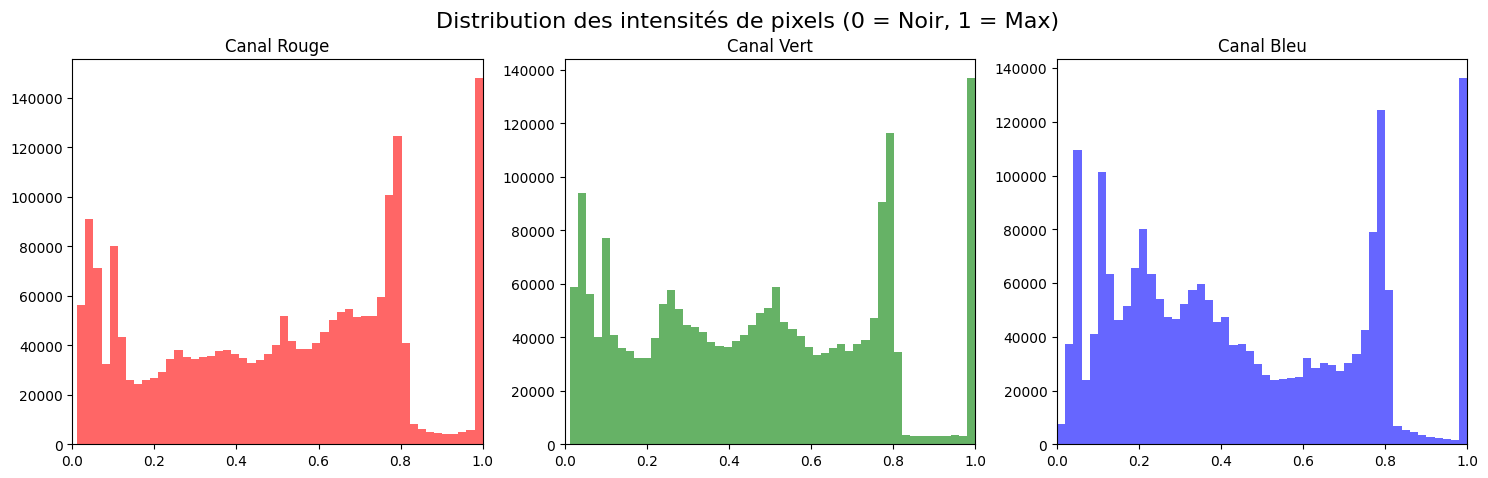

In [7]:
def plot_rgb_distribution(img_batch):
    # On aplatit les pixels de tout le batch par canal
    red   = img_batch[:, 0, :, :].flatten()
    green = img_batch[:, 1, :, :].flatten()
    blue  = img_batch[:, 2, :, :].flatten()

    fig, axs = plt.subplots(1, 3, figsize=(18, 5))
    
    # Rouge
    axs[0].hist(red, bins=50, color='red', alpha=0.6)
    axs[0].set_title("Canal Rouge")
    axs[0].set_xlim(0, 1)
    
    # Vert
    axs[1].hist(green, bins=50, color='green', alpha=0.6)
    axs[1].set_title("Canal Vert")
    axs[1].set_xlim(0, 1)
    
    # Bleu
    axs[2].hist(blue, bins=50, color='blue', alpha=0.6)
    axs[2].set_title("Canal Bleu")
    axs[2].set_xlim(0, 1)
    
    plt.suptitle("Distribution des intensités de pixels (0 = Noir, 1 = Max)", fontsize=16)
    plt.show()

plot_rgb_distribution(images)

In [19]:
import pandas as pd
df = dm.get_dataset(table="mvtec_ad", verbose=True)

print(df.shape)
print(df["split"].value_counts())
print(df["label"].value_counts())
print(df["category"].value_counts().head(20))


✅ 11767 lignes récupérées depuis 'mvtec_ad' (Triées par chemin).
(11767, 4)
split
train         7935
test          3293
validation     539
Name: count, dtype: int64
label
good                    9516
logical_anomalies        561
structural_anomalies     432
color                     93
scratch                   91
crack                     84
combined                  55
cut                       53
hole                      45
contamination             42
faulty_imprint            41
poke                      39
bent                      37
rough                     32
thread                    30
defective                 30
glue                      30
metal_contamination       28
scratch_neck              25
scratch_head              24
manipulated_front         24
thread_top                23
thread_side               23
flip                      23
broken_small              22
squeeze                   20
broken_large              20
broken_teeth              19
split_teeth      

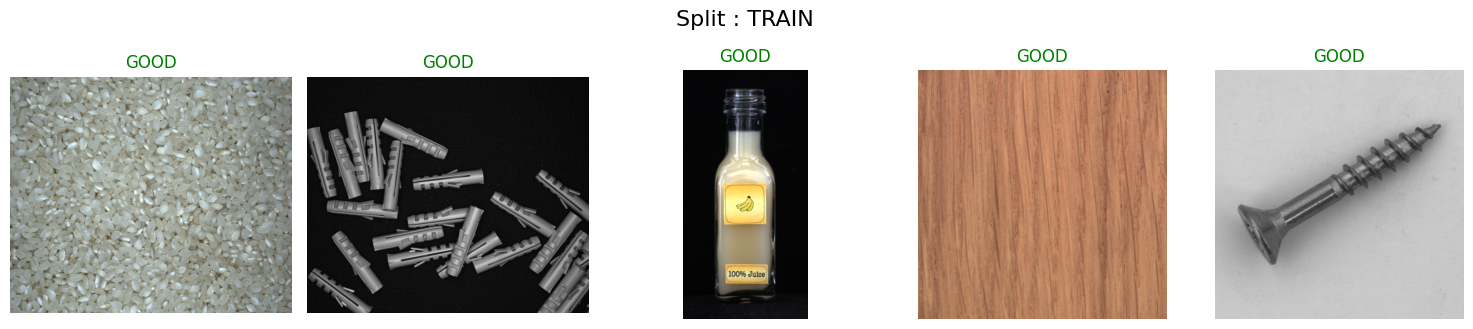

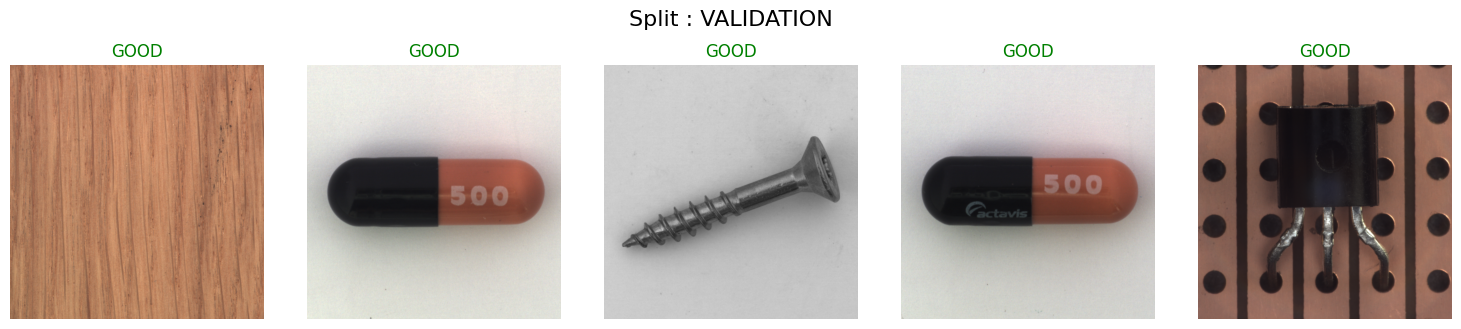

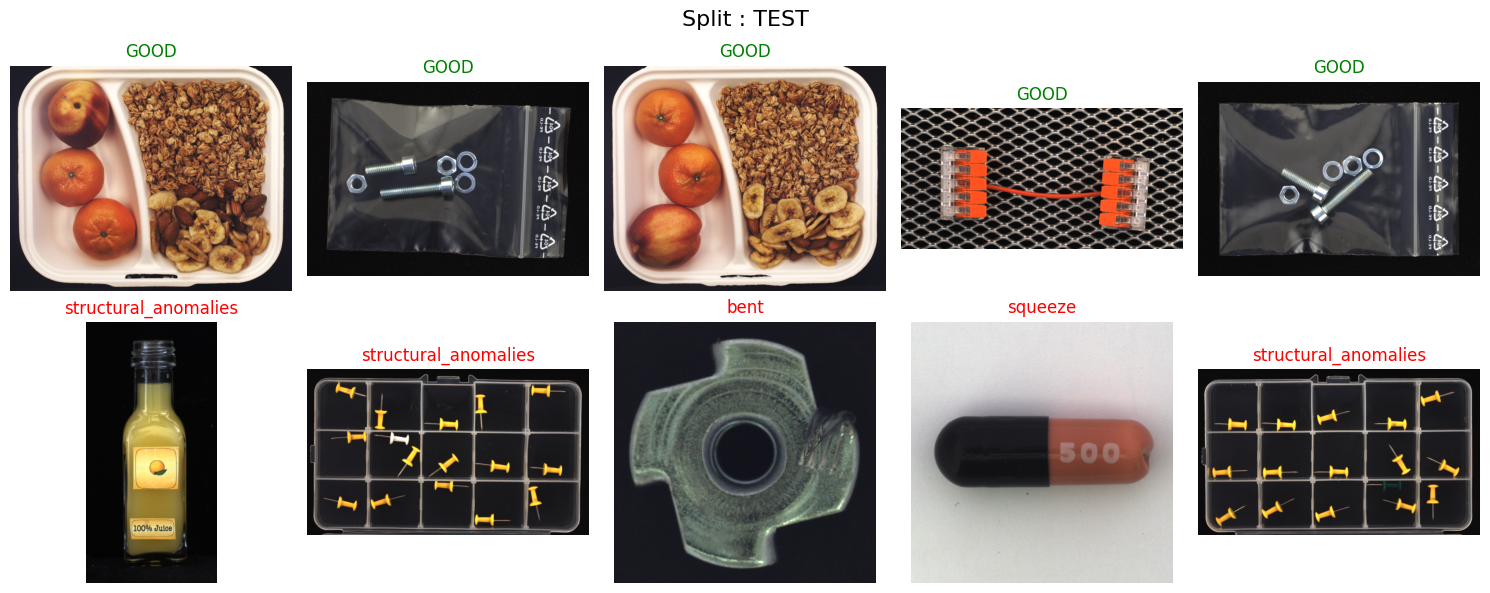

In [20]:
def show_good_vs_defect(df, split_name, n=5, seed=42):
    subset = df[df["split"] == split_name]
    
    good_df = subset[subset["label"] == "good"]
    defect_df = subset[subset["label"] != "good"]
    
    good_sample = good_df.sample(min(n, len(good_df)), random_state=seed)
    defect_sample = defect_df.sample(min(n, len(defect_df)), random_state=seed)
    
    plt.figure(figsize=(15, 6))
    
    # --- GOOD ---
    for i, (_, row) in enumerate(good_sample.iterrows()):
        img = dm.load_image(row["filepath"])
        plt.subplot(2, n, i + 1)
        plt.imshow(img)
        plt.title("GOOD", color="green")
        plt.axis("off")
    
    # --- DEFECT ---
    for i, (_, row) in enumerate(defect_sample.iterrows()):
        img = dm.load_image(row["filepath"])
        plt.subplot(2, n, n + i + 1)
        plt.imshow(img)
        plt.title(row["label"], color="red")
        plt.axis("off")
    
    plt.suptitle(f"Split : {split_name.upper()}", fontsize=16)
    plt.tight_layout()
    plt.show()

show_good_vs_defect(df, "train", n=5)
show_good_vs_defect(df, "validation", n=5)
show_good_vs_defect(df, "test", n=5)



In [21]:
import pandas as pd

df["is_anomaly"] = df["label"] != "good"
counts = pd.crosstab(df["split"], df["is_anomaly"])

# Renommer les colonnes
counts.columns = ["GOOD", "DEFECT"]

print(counts)


            GOOD  DEFECT
split                   
test        1042    2251
train       7935       0
validation   539       0


In [24]:
# Anomalies seulement
anom = df[df["label"] != "good"]

print("Top anomaly types:")
print(anom["label"].value_counts().head(15))

print("\nAnomalies by category (top):")
print(anom["category"].value_counts().head(15))


Top anomaly types:
label
logical_anomalies       561
structural_anomalies    432
color                    93
scratch                  91
crack                    84
combined                 55
cut                      53
hole                     45
contamination            42
faulty_imprint           41
poke                     39
bent                     37
rough                    32
glue                     30
defective                30
Name: count, dtype: int64

Anomalies by category (top):
category
juice_bottle           236
screw_bag              219
splicing_connectors    193
breakfast_box          173
pushpins               172
pill                   141
screw                  119
zipper                 119
capsule                109
metal_nut               93
leather                 92
cable                   92
carpet                  89
tile                    84
hazelnut                70
Name: count, dtype: int64


In [25]:
top_cats = df["category"].value_counts().head(10).index
top_labels = anom["label"].value_counts().head(10).index
mat = pd.crosstab(df["category"], df["label"]).loc[top_cats, top_labels]
print(mat)


label                logical_anomalies  structural_anomalies  color  scratch  \
category                                                                       
screw_bag                          137                    82      0        0   
pushpins                            91                    81      0        0   
splicing_connectors                108                    85      0        0   
juice_bottle                       142                    94      0        0   
breakfast_box                       83                    90      0        0   
hazelnut                             0                     0      0        0   
screw                                0                     0      0        0   
pill                                 0                     0     25       24   
carpet                               0                     0     19        0   
walnuts                              0                     0      0        0   

label                crack  combined  c